In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans, DBSCAN


## Load Dataset

In [33]:
wine = load_wine()

X = wine.data
y = wine.target

print(X.shape)


(178, 13)


In [34]:
df = pd.DataFrame(X)
df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [35]:
df.isnull().sum()


,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [36]:
df.duplicated().sum()


np.int64(0)

In [37]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled


array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

## Feature Correlation

In [38]:
# Calculate the correlation matrix of the scaled data
scaled_df = pd.DataFrame(X_scaled, columns=wine.feature_names)
correlation_matrix = scaled_df.corr()
display(correlation_matrix.head())


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351


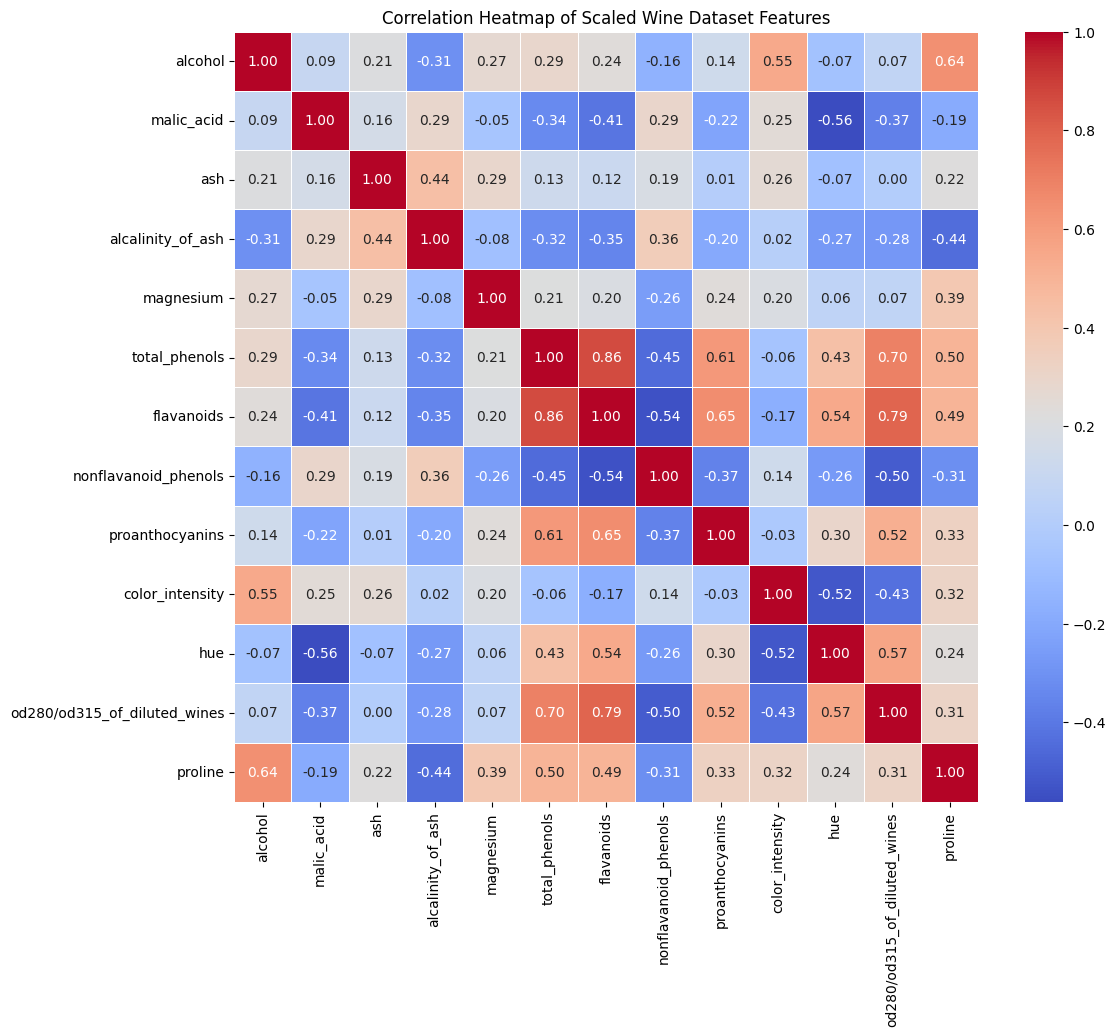

In [39]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Scaled Wine Dataset Features')
plt.show()


In [40]:
corr_pairs = correlation_matrix.unstack()
sorted_corr_pairs = corr_pairs.sort_values(ascending=False)

filtered_corr_pairs = sorted_corr_pairs[sorted_corr_pairs != 1.0]


unique_corr_list = []
seen_pairs = set()

for (feature1, feature2), correlation_value in filtered_corr_pairs.items():

    ordered_pair = tuple(sorted((feature1, feature2)))

    if ordered_pair not in seen_pairs:
        unique_corr_list.append(((feature1, feature2), correlation_value))
        seen_pairs.add(ordered_pair)


correlation_summary_df = pd.DataFrame(unique_corr_list, columns=['Feature Pair', 'Correlation'])

correlation_summary_df.head(10)


,Feature Pair,Correlation
0,"(flavanoids, total_phenols)",0.864564
1,"(flavanoids, od280/od315_of_diluted_wines)",0.787194
2,"(od280/od315_of_diluted_wines, total_phenols)",0.699949
3,"(flavanoids, proanthocyanins)",0.652692
4,"(alcohol, proline)",0.643720
5,"(total_phenols, proanthocyanins)",0.612413
6,"(hue, od280/od315_of_diluted_wines)",0.565468
7,"(color_intensity, alcohol)",0.546364
8,"(flavanoids, hue)",0.543479
9,"(proanthocyanins, od280/od315_of_diluted_wines)",0.519067


## K-Means before PCA

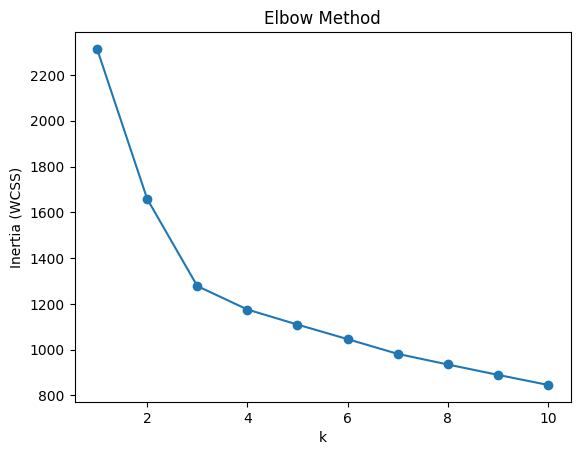

In [41]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()


In [42]:
sil_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}: silhouette = {score:.4f}")


k=2: silhouette = 0.2593
k=3: silhouette = 0.2849
k=4: silhouette = 0.2602
k=5: silhouette = 0.2016
k=6: silhouette = 0.2372
k=7: silhouette = 0.2036
k=8: silhouette = 0.1570


In [43]:
k_means = KMeans(n_clusters=3, random_state=42, n_init=10)
kme = k_means.fit_predict(X_scaled)
kme


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [44]:
sil_before = silhouette_score(X_scaled, kme)
ari_before = adjusted_rand_score(y, kme)

print(f"Silhouette (before PCA): {sil_before:.4f}")
print(f"ARI (before PCA): {ari_before:.4f}")


Silhouette (before PCA): 0.2849
ARI (before PCA): 0.8975


## PCA

In [45]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(178, 2)


In [46]:
k_meansPCA = KMeans(n_clusters=3, random_state=42, n_init=10)
kmePCA = k_meansPCA.fit_predict(X_pca)
kmePCA


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [47]:
sil_after = silhouette_score(X_pca, kmePCA)
ari_after = adjusted_rand_score(y, kmePCA)

print(f"Silhouette (after PCA): {sil_after:.4f}")
print(f"ARI (after PCA): {ari_after:.4f}")


Silhouette (after PCA): 0.5611
ARI (after PCA): 0.8951


Now, let's visualize these clusters on the PCA plot to see how well they separate the data.

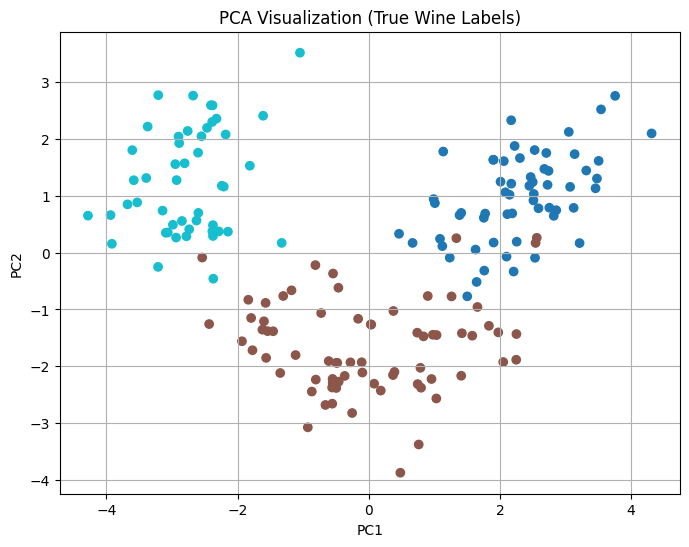

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10")
plt.title("PCA Visualization (True Wine Labels)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()


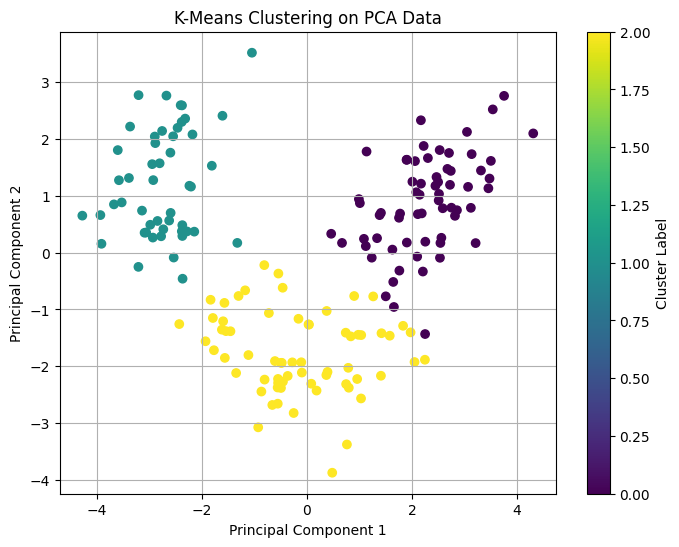

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmePCA, cmap="viridis")
plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster Label')
plt.grid()
plt.show()


In [50]:
comparison = pd.DataFrame({
    'Stage': ['Before PCA (13D)', 'After PCA (2D)'],
    'Silhouette': [sil_before, sil_after],
    'ARI vs true labels': [ari_before, ari_after]
})
comparison


,Stage,Silhouette,ARI vs true labels
0,Before PCA (13D),0.284859,0.897495
1,After PCA (2D),0.561051,0.895058


## Analysis

- **How did PCA affect clustering results?** Silhouette and ARI stayed close to each other before vs after PCA (see the comparison table above). K-Means found essentially the same groupings whether it worked on the full 13 features or the compressed 2D version
- **Did visualization become clearer?** Yes. 13 features can't be plotted directly, but the 2 PCA components let us see the 3 wine cultivars as distinct regions in a single scatter plot
- **Did we lose important information?** Some. the 2 components retain of the total variance, not 100%. But clustering quality barely changed, so what was kept captured the parts of the data that actually separate the wine types
- **Which approach is better?** After PCA. same clustering quality, much easier to visualize, and easier to compute


## Bonus: Trying Different Numbers of PCA Components

Instead of 2 components like the main pipeline above, here we try `n_components` from 2 to 10 and re-run PCA + K-Means each time, to check whether 2 was actually a reasonable choice or just convenient for plotting


In [51]:
bonus = []
for n in range(2,11):
  npca = PCA(n_components=n, random_state=42)
  nx = npca.fit_transform(X_scaled)

  nkmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
  nlabels = nkmeans.fit_predict(nx)
  bonus.append({
      'NComponents': n,
      'Variance': npca.explained_variance_ratio_.sum(), #how much of the original information those n components preserve (0 to 1)
      'Silhouette': silhouette_score(nx, nlabels), #how well separated the clusters are from the data itself
      'ARI': adjusted_rand_score(y, nlabels) #how well the cluster labels match the true wine cultivar labels
  })

bonusdf = pd.DataFrame(bonus)
bonusdf


,NComponents,Variance,Silhouette,ARI
0,2,0.554063,0.561051,0.895058
1,3,0.665300,0.453235,0.880400
2,4,0.735990,0.406597,0.847097
3,5,0.801623,0.369076,0.897495
4,6,0.850981,0.346257,0.897495
5,7,0.893368,0.327635,0.897495
6,8,0.920175,0.314970,0.897495
7,9,0.942397,0.305783,0.897495
8,10,0.961697,0.298675,0.897495


plot how each metric moves as we add more components

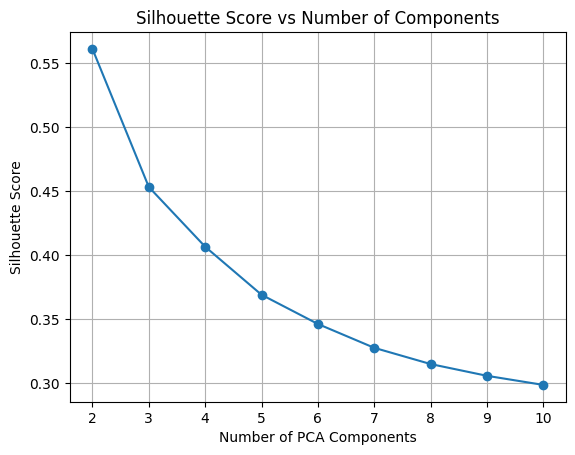

In [52]:
plt.plot(bonusdf['NComponents'], bonusdf['Silhouette'], marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Components')
plt.grid()
plt.show()


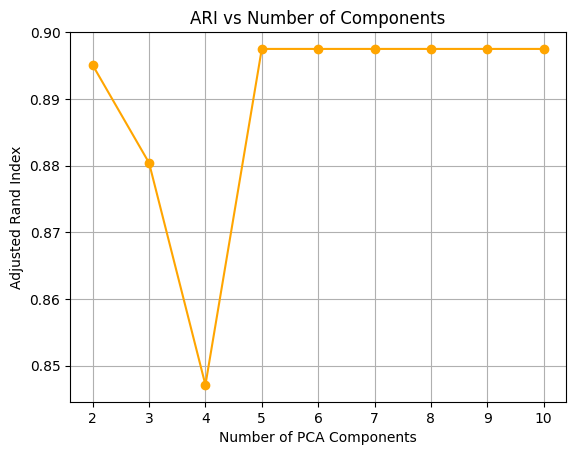

In [53]:
plt.plot(bonusdf['NComponents'], bonusdf['ARI'], marker='o', color='orange')
plt.xlabel('Number of PCA Components')
plt.ylabel('Adjusted Rand Index')
plt.title('ARI vs Number of Components')
plt.grid()
plt.show()


**Insights (for n_components):**

- Silhouette score drops as we add more components, but that's not "worse clustering." Silhouette is based on distance, and distances naturally get less meaningful the more dimensions you add, so this metric is a bit biased toward low dimensions
- ARI (against the wine labels) stays flat or improves a little with more components, meaning the clusters are still just as correct, the silhouette drop is mostly a side effect of the metric itself, not the model getting worse
- Key takeaway: **more components isn't automatically better, and fewer components isn't automatically worse!** For this dataset, sticking with 2 components (like we did in the main pipeline) turns out to be a solid choice, not just a convenient one for plotting. the clustering accuracy is high while staying easy to visualize


## Bonus: Compare with DBSCAN

DBSCAN doesn't need a fixed number of clusters because it groups points based on density and marks sparse points as noise (`-1`). It's very sensitive to two settings: `eps` (neighborhood radius) and `min_samples` (how many neighbors are needed to count as "dense"). here we try a few `eps` values on the same `X_pca` data used above, to see how sensitive the result is


In [54]:
eps_values = np.arange(0.2, 1.0, 0.05)
min_samples_values = [3, 4, 5, 6, 7, 8]

best_score = -1
best_params = {}
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca)


        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)


        if n_clusters > 1:
            score = silhouette_score(X_pca, labels)

            results.append({
                'eps': round(eps, 2),
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'silhouette_score': round(score, 4)
            })


            if score > best_score:
                best_score = score
                best_params = {'eps': round(eps, 2), 'min_samples': min_samples}


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='silhouette_score', ascending=False)


print(f"Best Params: {best_params} | Best Silhouette Score: {best_score:.4f}\n")


results_df.head(10)

Best Params: {'eps': np.float64(0.65), 'min_samples': 8} | Best Silhouette Score: 0.4254



,eps,min_samples,n_clusters,n_noise,silhouette_score
53,0.65,8,3,22,0.4254
39,0.55,5,3,23,0.4082
65,0.80,6,2,5,0.3778
68,0.85,8,2,5,0.3778
64,0.80,5,2,5,0.3778
67,0.80,8,2,6,0.3731
66,0.80,7,2,6,0.3731
56,0.70,6,2,8,0.3686
49,0.65,4,2,7,0.3566
47,0.60,7,4,27,0.3559


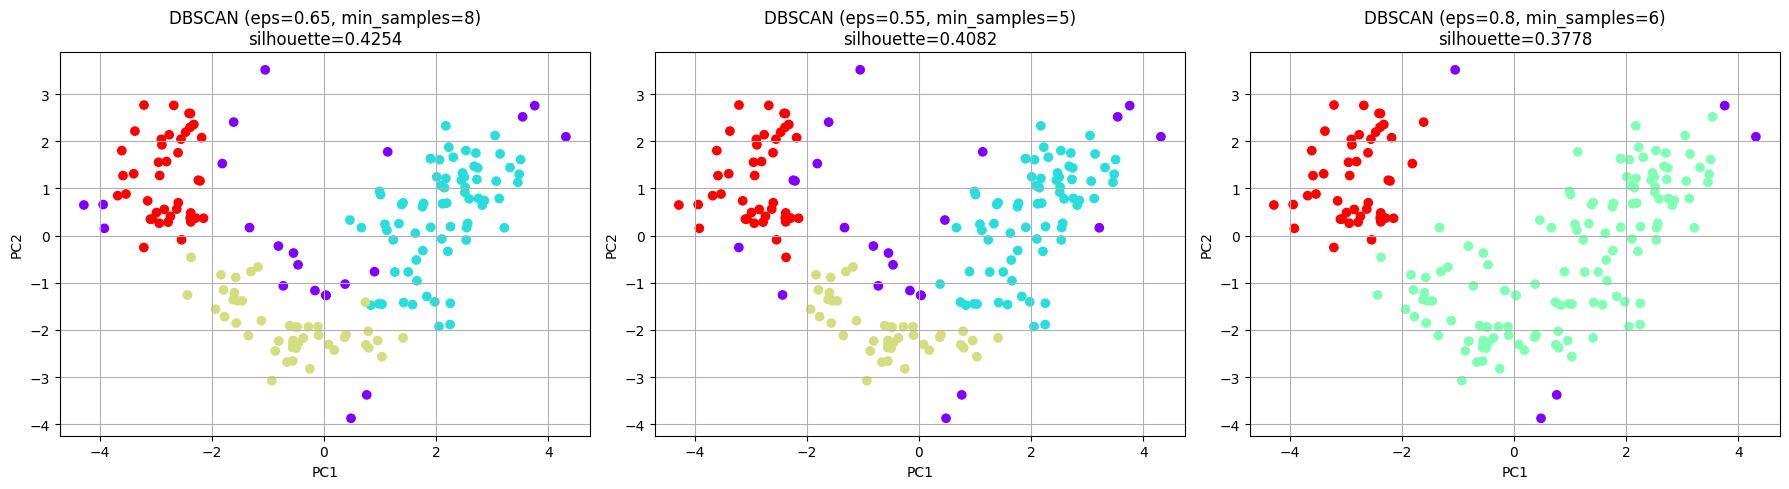

In [55]:
top3 = results_df.head(3).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, row in zip(axes, top3.itertuples()):
    db = DBSCAN(eps=row.eps, min_samples=row.min_samples)
    labels_db = db.fit_predict(X_pca)
    scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, cmap="rainbow")
    ax.set_title(f"DBSCAN (eps={row.eps}, min_samples={row.min_samples})\nsilhouette={row.silhouette_score}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid()

plt.tight_layout()
plt.show()

**Insights (DBSCAN):**

- DBSCAN figures out the number of clusters on its own from the density of points, and flags anything too sparse as noise (`-1`)
- Changing `eps` changes the result a lot: a small `eps` tends to leave more points labeled as noise and can split real groups apart; a large `eps` merges groups together, and might collapse everything into one big cluster
- On this dataset, the wine clusters in PCA space are fairly round and well-separated. even with reasonable `eps` tuning, DBSCAN doesn't beat K-Means here (comparing its `Silhouette`/`ARI` to the K-Means-after-PCA row from earlier)
- Takeaway: DBSCAN is a great choice when clusters are irregular shapes or when we don't know `k` ahead of time, but for compact data like wine, K-Means is simpler and performs well


## Final Summary (Key Insights)

1. Clustering quality barely changed between using all 13 features and using just 2 PCA components. PCA didn't do meaningful accuracy here
2. PCA made the results visualizable. because we cant plot 13 dimensions. so we can do a clear 2D scatter plot showing the 3 wine types
3. Adding more than 2 PCA components doesn't clearly improve clustering (ARI stays about the same), even though it makes the silhouette score look worse, that drop is a because of the metric, not proof of worse clusters
4. DBSCAN is a reasonable alternative but is more sensitive to its parameters, and doesn't outperform K-Means on this dataset since the wine clusters are naturally round and well separated
5. Overall: 2 components + K-Means (k=3) is a justified choice for this dataset
